In [1]:
import os

os.chdir("..")
from fourm.data.multimodal_dataset_folder import MultiModalDatasetFolder
from fourm.data.modality_transforms import DepthTransform, UnifiedDataTransform
from fourm.data.image_augmenter import RandomRotationImageAugmenter
import torch
import sys
torch.set_printoptions(threshold=sys.maxsize, linewidth=sys.maxsize)

/u/cohanlon/micromamba/envs/sarformer/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
INFO:albumentations.check_version:A new version of Albumentations is available: 1.4.14 (you have 1.4.12). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
INFO:datasets:PyTorch version 2.4.0 available.


In [ ]:
depth_transform = DepthTransform(standardize_depth=True)
MODALITY_TRANSFORMS_DIVAE = {"depth": depth_transform}
image_augmenter_train = RandomRotationImageAugmenter(near_orthogonal=False)
# all modalities
transforms_train = UnifiedDataTransform(
    transforms_dict=MODALITY_TRANSFORMS_DIVAE,
    image_augmenter=image_augmenter_train,
    resample_mode="bicubic",
    add_sizes=False,
)
dataset_train = MultiModalDatasetFolder(
    root="/scratch/bdej/cohanlon/unsupervised/train",
    modalities=["depth", "mask_valid"],
    modality_paths={"depth": "depth"},
    modality_info={"depth": {"no_data_value": -9999.0, "num_channels": 1}},
    modality_transforms=MODALITY_TRANSFORMS_DIVAE,
    transform=transforms_train,
    cache=False,
)


In [ ]:
dataset_train[0]["depth"]

KeyboardInterrupt: 

In [ ]:
dataset_train[0]["depth"]

<PIL.TiffImagePlugin.TiffImageFile image mode=F size=512x512>

<Figure size 640x480 with 0 Axes>

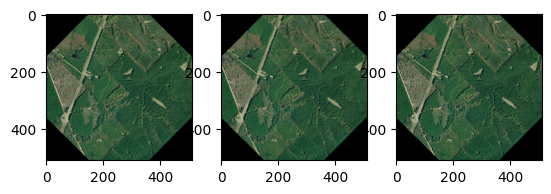

In [ ]:
from PIL import Image
import torchvision.transforms.functional as TF
from matplotlib import pyplot as plt

im = Image.open("/scratch/bdej/cohanlon/unlabeled/train/rgb/million-case/NAIP_220683.jpg")
im1 = TF.rotate(im, 45.4, Image.Resampling.NEAREST)
im2 = TF.rotate(im, 45.4, Image.Resampling.BILINEAR)
im3 = TF.rotate(im, 45.4, Image.Resampling.BICUBIC)

plt.figure()
f, axarr = plt.subplots(1, 3)
axarr[0].imshow(im1)
axarr[1].imshow(im2)
axarr[2].imshow(im3)

plt.show()

In [ ]:
from fourm.data.modality_transforms import RGBTransform
from fourm.data.modality_info import MODALITY_INFO
import torch


def setup_modality_info(args):
    """Sets up the modality info dictionary for the given domains."""
    modality_info = {mod: MODALITY_INFO[mod] for mod in args}
    return modality_info


modality_info = setup_modality_info(["rgb"])
modality_paths = {"rgb": "rgb"}

MODALITY_TRANSFORMS_DIVAE = {}
MODALITY_TRANSFORMS_DIVAE["rgb"] = RGBTransform(
    mean_and_std="naip", color_jitter=False, no_data_value=0
)

image_augmenter_train = RandomRotationImageAugmenter(near_orthogonal=True)

transforms_train = UnifiedDataTransform(
    transforms_dict=MODALITY_TRANSFORMS_DIVAE,
    image_augmenter=image_augmenter_train,
    resample_mode="bicubic",
    add_sizes=False,
)

dataset_train = MultiModalDatasetFolder(
    root="/scratch/bdej/cohanlon/unlabeled/train",
    modalities=["rgb", "mask_valid"],
    modality_paths=modality_paths,
    modality_transforms=MODALITY_TRANSFORMS_DIVAE,
    modality_info=modality_info,
    transform=transforms_train,
    cache=False,
)

sampler_train = torch.utils.data.DistributedSampler(
    dataset_train,
    num_replicas=1,
    rank=0,
    shuffle=True,
    drop_last=True,
)

data_loader_train = torch.utils.data.DataLoader(
    dataset_train,
    sampler=sampler_train,
    batch_size=64,
    num_workers=1,
    pin_memory=False,
    drop_last=True,
)

In [ ]:
import time

start = time.time()
for i in range(4):
    next(iter(data_loader_train))
print(time.time() - start)


21.816264152526855


In [ ]:
dataset_train.class_to_idx

{'sar': 0, 'million-case': 1}

0.9252638816833496 0.0 1.0 0.9236286878585815 0.031481992453336716


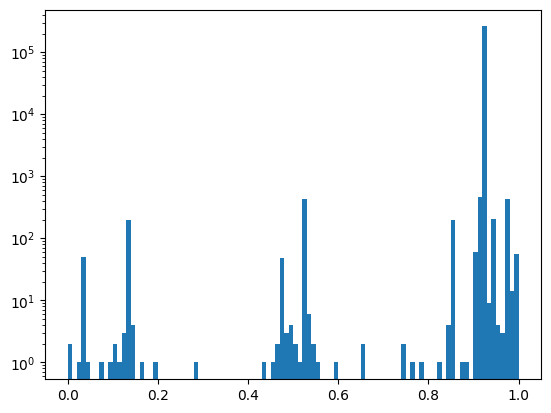

In [ ]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from fourm.data.modality_transforms import DepthTransform

depth_transform = DepthTransform(no_data_value=-9999.0)

# im = Image.open(
#     "/scratch/bdej/cohanlon/unsupervised/train/depth/million-case/DEM_270091.tif"
# )
im = Image.open(
    "/scratch/bdej/cohanlon/unsupervised/train/depth/million-case/DEM_901.tif"
)
t = depth_transform.image_augment(im, None, None, 0, None, None, None, "bilinear")
t = depth_transform.postprocess(t)
t = depth_transform.depth_minmax_scaling(t)

t_prime = t.flatten()
mean = t_prime.mean().item()
std = t_prime.std().item()

print(t_prime.mode()[0].item(), t_prime.min().item(), t_prime.max().item(), t_prime.mean().item(), t_prime.std().item())
plt.hist(t.flatten(), log=True, bins=100)
# t = depth_transform.truncated_depth_standardization(t)
plt.show()

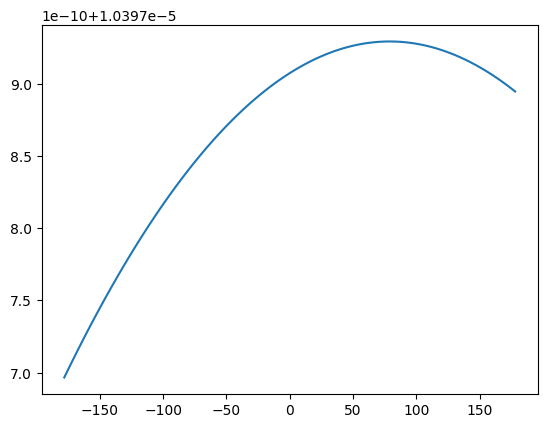

In [ ]:
from scipy.stats import norm
plt.plot(np.linspace(-178, 178, 100), norm.pdf(np.linspace(-178, 178, 100), loc=mean, scale=std))
plt.show()

In [ ]:
from PIL import Image
import numpy as np
import torchvision.transforms.functional as TF
im = Image.open("/scratch/bdej/cohanlon/unsupervised/train/rgb/million-case/NAIP_90181.jpg")
TF.to_tensor(im).shape

torch.Size([3, 512, 512])

In [ ]:
import numpy as np
import torch

test = np.array([[-np.inf, 2, 3], [4, 5, np.inf], [-9999.0, np.nan, 9]])
test = np.expand_dims(test, 0)
test

array([[[      -inf,  2.000e+00,  3.000e+00],
        [ 4.000e+00,  5.000e+00,        inf],
        [-9.999e+03,        nan,  9.000e+00]]])

In [ ]:
test = torch.tensor(test)
test

tensor([[[       -inf,  2.0000e+00,  3.0000e+00],
         [ 4.0000e+00,  5.0000e+00,         inf],
         [-9.9990e+03,         nan,  9.0000e+00]]], dtype=torch.float64)

In [ ]:
no_data_mods = ["depth"]
sample_dict = {"depth": test}
modality_info = {"depth": {"no_data_value": -9999.0, "num_channels": 1}}

channel_dim = 0
H, W = sample_dict[no_data_mods[0]].shape[1:3]
mask = torch.ones(1, H, W, dtype=torch.bool)
for mod in no_data_mods:
    sample = sample_dict[mod]
    assert sample.shape[channel_dim] == modality_info[mod]["num_channels"]
    no_data_value = modality_info[mod]["no_data_value"]

    no_data_mask = (sample != no_data_value).all(dim=channel_dim, keepdim=True)
    nan_mask = np.isfinite(sample).any(dim=channel_dim, keepdim=True)
    mask = mask & no_data_mask & nan_mask

mask

tensor([[[0, 1, 1],
         [1, 1, 0],
         [0, 0, 1]]], dtype=torch.uint8)

(64, 2, 224, 224)

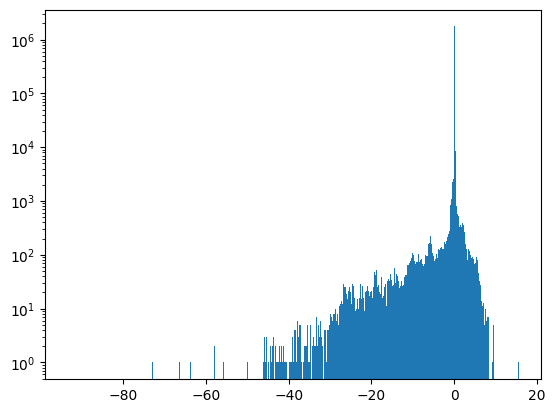

(0.061434757, 0.9136746, -93.47015, 15.583456)

In [ ]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.stats import norm

arr = np.load("../clean_images.npy")
arr = arr[:, 0].flatten()
arr = arr[arr != 0]
mean = arr.mean()
std =  arr.std()


# def reject_outliers(data, m=2.0):
#     d = np.abs(data - np.median(data))
#     mdev = np.median(d)
#     s = d / mdev if mdev else np.zeros(len(d))
#     return data[s < m]

# arr = reject_outliers(arr, 3)

plt.hist(arr, bins=1000, log=True, density=False)
plt.show()
arr.mean(), arr.std(), arr.min(), arr.max()

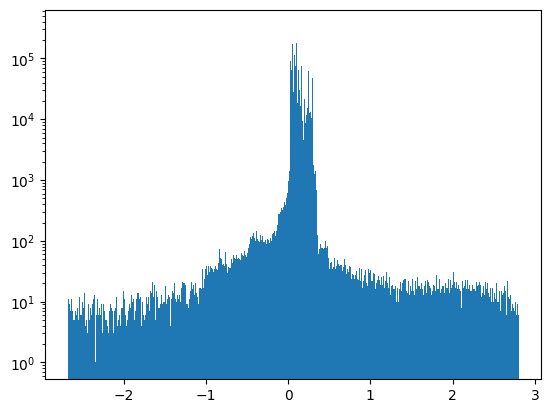

(0.10377678, 0.12507977, -2.6794398, 2.8008363)

In [ ]:
arr_trim = arr[(arr > mean - 3 * std) & (arr < mean + 3 * std)]

plt.hist(arr_trim, bins=1000, log=True, density=False)
plt.show()
arr_trim.mean(), arr_trim.std(), arr_trim.min(), arr_trim.max()

-0.7557651 -0.14858048 0.010143193 0.612903 -13.981074 15.416461


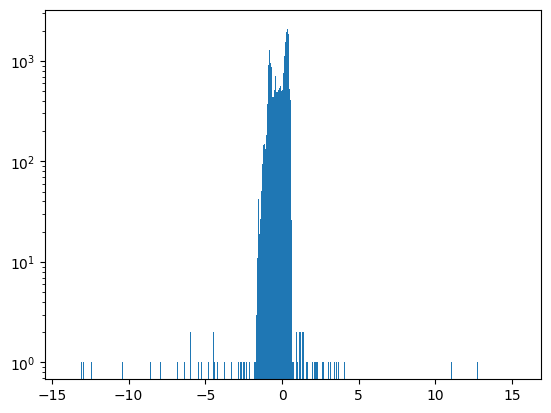

Remaining: 96.29 %


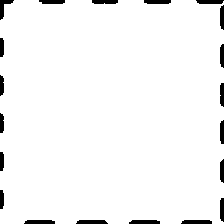

In [40]:
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from scipy.stats import mode, iqr
import torch
arr = np.array(Image.open("/scratch/bdej/cohanlon/unsupervised/train/depth/million-case/DEM_987999.tif"))

from fourm.data.modality_transforms import DepthTransform

arr = np.expand_dims(arr, axis=0)

arr = arr.transpose(1, 2, 0)
arr = torch.tensor(arr)

mask = DepthTransform.depth_artifact_mask(arr, outlier_threshold=16)

arr = DepthTransform.depth_robust_scaling(arr)

arr[~mask] = 0

# # Robust scaling
# arr[arr == -9999.0] = 0
# arr = (arr - np.median(arr[arr != 0])) / iqr(arr[arr != 0])

# # Robust trimming
# dists_from_median = np.abs(arr - np.median(arr[arr != 0]))
# dists_in_iqrs = dists_from_median / iqr(arr[arr != 0])
# outlier_threshold = 7
# # make removed pix (the outliers) black
# arr[dists_in_iqrs > outlier_threshold] = 0

d_arr = arr[arr != 0].numpy().flatten()
print(mode(d_arr).mode, d_arr.mean(), np.median(d_arr), d_arr.std(), d_arr.min(), d_arr.max())
plt.hist(d_arr, bins=1000, log=True, density=False)
plt.show()

# make kept pix white
# arr[dists_in_iqrs <= outlier_threshold] = 1

arr[mask] = 1

print("Remaining:", round(len(arr[mask]) / 224 ** 2 * 100, 2), "%") 

arr = (arr.numpy() * 255).astype(np.uint8).repeat(3, axis=2)
im = Image.fromarray(arr)
im

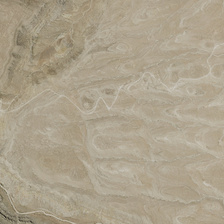

In [ ]:
Image.open("/scratch/bdej/cohanlon/unsupervised/train/rgb/million-case/NAIP_8400.jpg")